# Use model

In [9]:
import numpy as np
import random
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from model import SuperResDiffusionUNet,Upsampler,SuperResolutionDiffusion
from dataset import SuperResolutionDataset

/tmp/ipykernel_2765268/3455242110.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():


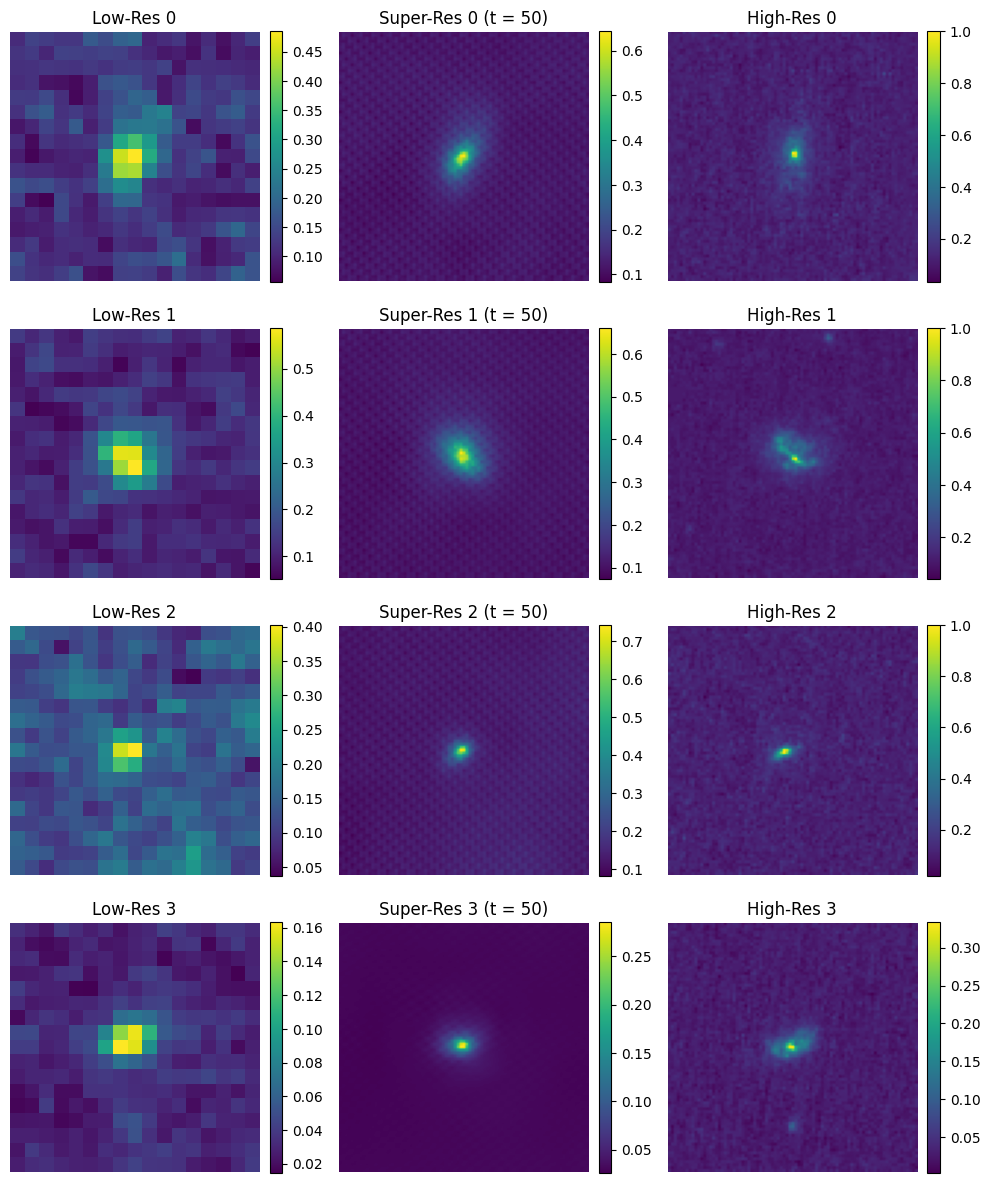

In [28]:
# Load model
checkpoint_path = "wandb/run-20250617_071647-sz458zjd/files/best_model.pth"
#checkpoint_path = "wandb/run-20250616_185638-qr71s2s8/files/best_model.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

unet = SuperResDiffusionUNet(in_channels=1, out_channels=1).to(device)
upsampler = Upsampler().to(device)
model = SuperResolutionDiffusion(unet, upsampler).to(device)

model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

# Define DataLoader with num_workers for speed

test_loader = DataLoader(
    SuperResolutionDataset("../data/Nisp_train_cosmos.hdf5", "../data/Nircam_train_cosmos.hdf5", split="test", sample_fraction=1),
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)


# === Pick a random test batch ===
random_batch_idx = random.randint(0, len(test_loader) - 1)
for i, (lr_batch, hr_batch) in enumerate(test_loader):
    if i == random_batch_idx:
        break

lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

# === Inference with timestep t (adjustable) ===
t_value = 50 # You can try 0, 50, 100, 250, etc.
t_test = torch.full((lr_batch.shape[0],), t_value, dtype=torch.long, device=device)

with torch.no_grad(), torch.cuda.amp.autocast():
    sr_batch = model(lr_batch, t_test).cpu()

# === Convert to numpy for visualization ===
lr_batch_np = lr_batch.cpu().squeeze().numpy()
sr_batch_np = sr_batch.squeeze().numpy()
hr_batch_np = hr_batch.cpu().squeeze().numpy()

# === Plot results ===
num_images = min(4, lr_batch.shape[0])
fig, axes = plt.subplots(num_images, 3, figsize=(10, 12))

for i in range(num_images):
    # Low-Res
    img1 = axes[i, 0].imshow(lr_batch_np[i][4:-4,4:-4])
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)

    # Super-Resolved (Refined)
    img2 = axes[i, 1].imshow(sr_batch_np[i][20:-20,20:-20])
    axes[i, 1].set_title(f"Super-Res {i} (t = {t_value})")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)

    # High-Res Ground Truth
    img3 = axes[i, 2].imshow(hr_batch_np[i][20:-20,20:-20])
    axes[i, 2].set_title(f"High-Res {i}")
    axes[i, 2].axis("off")
    fig.colorbar(img3, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

